In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('heart.csv')
df.head()


   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease
0   56   M           ASY        162          289          1        LVH    136              Y      1.6     Flat             1
1   51   M           NAP        119          196          0     Normal    139              N      0.3     Flat             0
2   51   M           ASY        121            0          0     Normal    104              N     -0.2     Flat             1
3   65   F           NAP        155          269          0     Normal    148              N      0.8       Up             0
4   59   M           NAP        146          214          1     Normal    160              N      1.0       Up             0


In [3]:
df.columns


Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')


In [4]:
df.shape


(15000, 12)


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             15000 non-null  int64  
 1   Sex             15000 non-null  str    
 2   ChestPainType   15000 non-null  str    
 3   RestingBP       15000 non-null  int64  
 4   Cholesterol     15000 non-null  int64  
 5   FastingBS       15000 non-null  int64  
 6   RestingECG      15000 non-null  str    
 7   MaxHR           15000 non-null  int64  
 8   ExerciseAngina  15000 non-null  str    
 9   Oldpeak         15000 non-null  float64
 10  ST_Slope        15000 non-null  str    
 11  HeartDisease    15000 non-null  int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 1.6 MB


In [6]:
df.describe()


                Age     RestingBP   Cholesterol     FastingBS         MaxHR       Oldpeak  HeartDisease
count  15000.000000  15000.000000  15000.000000  15000.000000  15000.000000  15000.000000  15000.000000
mean      53.633600    132.206667    199.049600      0.236200    137.053067      0.892487      0.553333
std        8.344323     16.214944    108.292706      0.424761     24.026895      0.894080      0.497164
min       28.000000      0.000000      0.000000      0.000000     60.000000     -2.600000      0.000000
25%       48.000000    121.000000    176.000000      0.000000    120.000000      0.100000      0.000000
50%       54.000000    131.000000    223.000000      0.000000    138.000000      0.700000      1.000000
75%       60.000000    141.000000    268.000000      0.000000    155.000000      1.500000      1.000000
max       77.000000    200.000000    603.000000      1.000000    202.000000      6.200000      1.000000


In [7]:
df.duplicated().sum()


np.int64(12)


In [8]:
df.isnull().sum()


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0


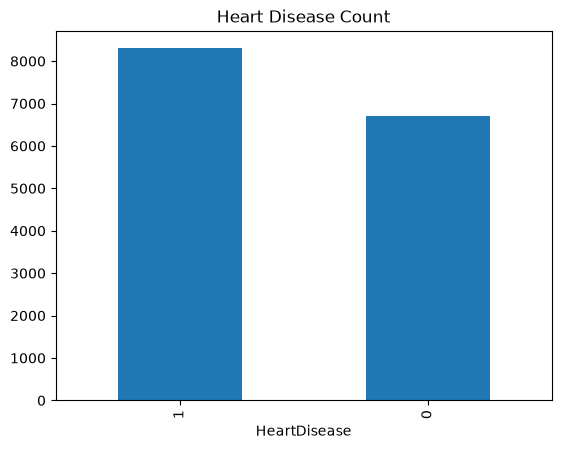

In [9]:
df['HeartDisease'].value_counts().plot(kind='bar')
plt.title('Heart Disease Count')
plt.show()


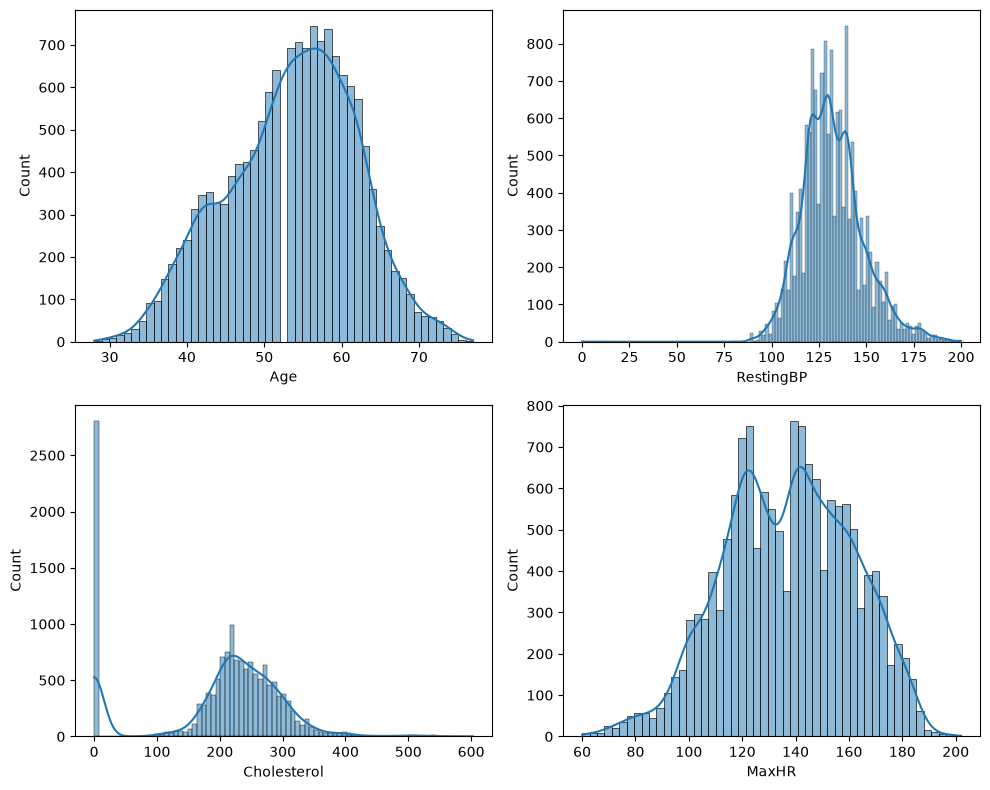

In [10]:
def plotting(var, num):
    plt.subplot(2, 2, num)
    sns.histplot(df[var], kde=True)

plt.figure(figsize=(10, 8))
plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)
plt.tight_layout()
plt.show()


In [11]:
# Checking 0 values in Cholesterol and RestingBP
print("Cholesterol with 0:", (df['Cholesterol'] == 0).sum())
print("RestingBP with 0:", (df['RestingBP'] == 0).sum())


Cholesterol with 0: 2809
RestingBP with 0: 1


In [12]:
# Replacing 0 in Cholesterol with Mean
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)
ch_mean


np.float64(244.9137888606349)


In [13]:
# Replacing 0 in RestingBP with Mean
resting_bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0, resting_bp_mean)
df['RestingBP'] = df['RestingBP'].round(2)
resting_bp_mean


np.float64(132.2154810320688)


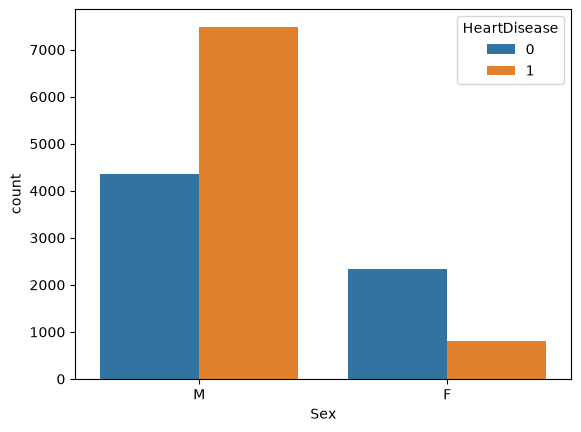

In [14]:
# Categorical Data Analysis with Plots
sns.countplot(x=df['Sex'], hue=df['HeartDisease'])
plt.show()


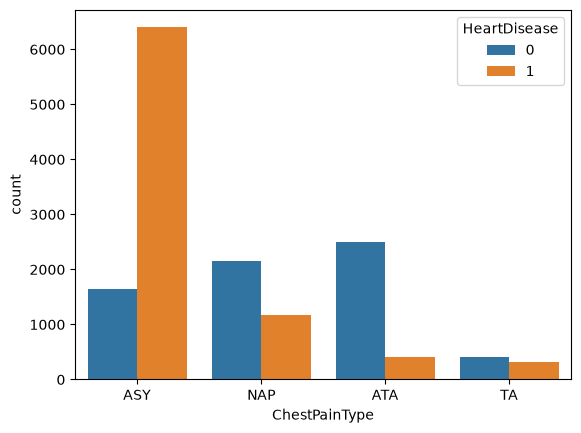

In [15]:
sns.countplot(x=df['ChestPainType'], hue=df['HeartDisease'])
plt.show()


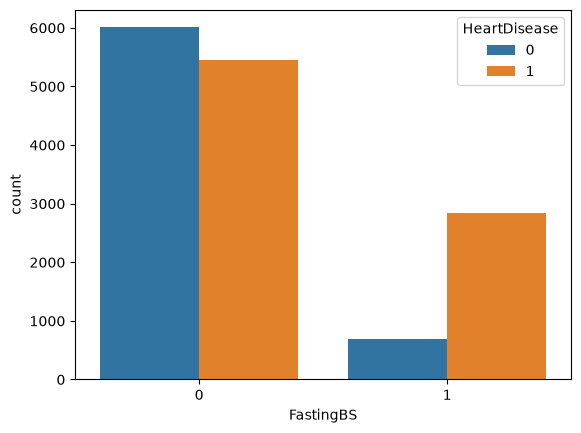

In [16]:
sns.countplot(x=df['FastingBS'], hue=df['HeartDisease'])
plt.show()


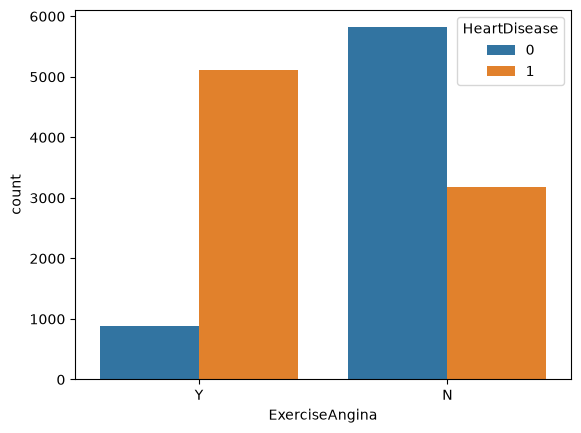

In [17]:
sns.countplot(x=df['ExerciseAngina'], hue=df['HeartDisease'])
plt.show()


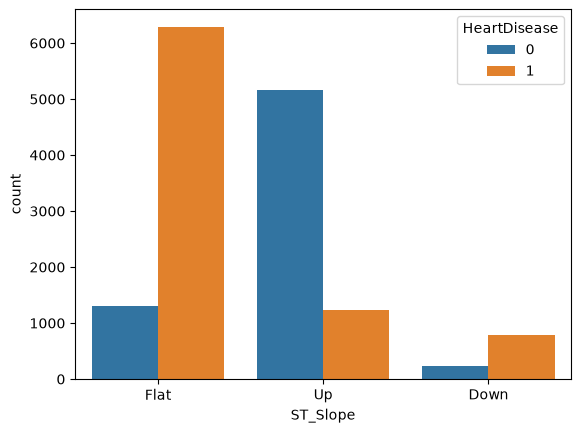

In [18]:
sns.countplot(x=df['ST_Slope'], hue=df['HeartDisease'])
plt.show()


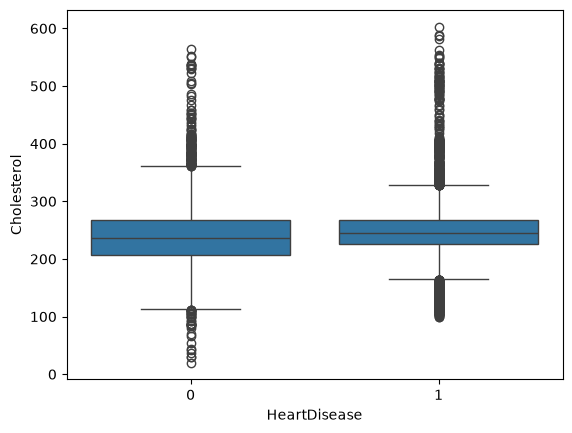

In [19]:
sns.boxplot(x='HeartDisease', y='Cholesterol', data=df)
plt.show()


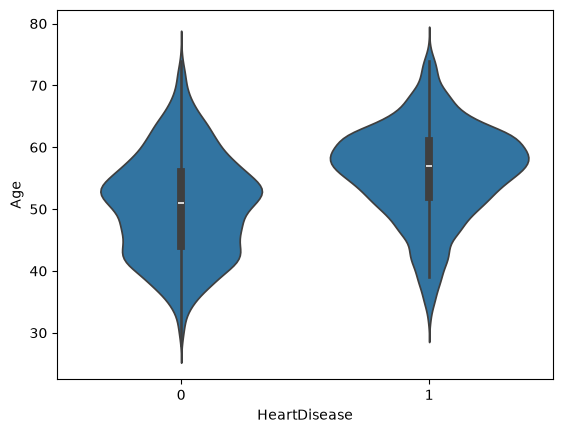

In [20]:
sns.violinplot(x='HeartDisease', y='Age', data=df)
plt.show()


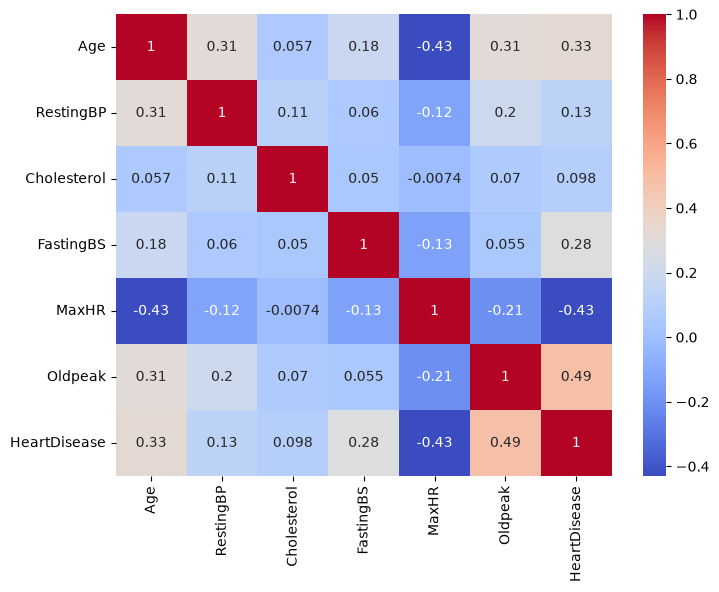

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


In [22]:
# One-hot encoding for categorical columns
df_encode = pd.get_dummies(df, drop_first=True, dtype=int)
df_encode.head()


   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  ST_Slope_Up
0   56      162.0       289.00          1    136      1.6             1      1                  0                  0                 0                  0              0                 1              1            0
1   51      119.0       196.00          0    139      0.3             0      1                  0                  1                 0                  1              0                 0              1            0
2   51      121.0       244.91          0    104     -0.2             1      1                  0                  0                 0                  1              0                 0              1            0
3   65      155.0       269.00          0    148      0.8             0      0                  0                  1                 0      

In [23]:
# Separate X (features) and y (target)
X = df_encode.drop('HeartDisease', axis=1)
y = df_encode['HeartDisease']
X.head()


   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  ST_Slope_Up
0   56      162.0       289.00          1    136      1.6      1                  0                  0                 0                  0              0                 1              1            0
1   51      119.0       196.00          0    139      0.3      1                  0                  1                 0                  1              0                 0              1            0
2   51      121.0       244.91          0    104     -0.2      1                  0                  0                 0                  1              0                 0              1            0
3   65      155.0       269.00          0    148      0.8      0                  0                  1                 0                  1              0                 0              0         

In [24]:
y


0        1
1        0
2        1
3        0
4        0
5        0
6        0
7        0
8        0
9        0
10       1
11       0
12       1
13       0
14       0
15       0
16       1
17       1
18       1
19       0
20       0
21       0
22       0
23       1
24       0
25       0
26       0
27       0
28       1
29       1
30       0
31       0
32       0
33       1
34       1
35       1
36       0
37       0
38       1
39       0
40       1
41       0
42       1
43       0
44       1
45       1
46       1
47       1
48       1
49       0
50       1
51       0
52       0
53       1
54       1
55       0
56       1
57       1
58       1
59       1
60       0
61       1
62       1
63       1
64       0
65       0
66       1
67       0
68       1
69       1
70       1
71       1
72       1
73       1
74       1
75       0
76       0
77       0
78       0
79       0
80       1
81       0
82       0
83       0
84       0
85       1
86       0
87       0
88       1
89       1
90       1

In [25]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (12000, 15)
X_test shape: (3000, 15)


In [26]:
# Feature Scaling with StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Note: On X_test we use transform (not fit_transform) to avoid data leakage
X_test_scaled = scaler.transform(X_test)


In [27]:
# Importing ML models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

result = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    result.append({
        'model': name,
        'Accuracy': round(acc * 100, 2),
        'f1 score': round(f1, 4)
    })

result_df = pd.DataFrame(result)
result_df


                 model  Accuracy  f1 score
0  Logistic Regression     88.17    0.8943
1                  KNN     94.63    0.9511
2          Naive Bayes     88.37    0.8953
3        Decision Tree     93.87    0.9446
4        Random Forest     96.90    0.9721


In [28]:
# Classification report for Logistic Regression
lr_model = models['Logistic Regression']
y_pred_lr = lr_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.88      0.85      0.87      1340
           1       0.88      0.90      0.89      1660

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000



In [29]:
# Save trained model, scaler and columns for Streamlit Frontend
import joblib
import json

joblib.dump(models['Logistic Regression'], 'LogisticReg_heartdisease.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns.pkl')

y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
metrics = {
    "accuracy": round(float(accuracy_score(y_test, y_pred_lr)) * 100, 2),
    "f1_score": round(float(f1_score(y_test, y_pred_lr)), 4),
    "precision": round(float(precision_score(y_test, y_pred_lr)), 4),
    "recall": round(float(recall_score(y_test, y_pred_lr)), 4),
    "roc_auc": round(float(roc_auc_score(y_test, y_proba_lr)), 4),
    "feature_columns": X.columns.tolist(),
    "cholesterol_mean": round(float(ch_mean), 2),
    "resting_bp_mean": round(float(resting_bp_mean), 2)
}

with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print("All artifacts saved successfully (LogisticReg_heartdisease.pkl, scaler.pkl, columns.pkl, metrics.json)")


All artifacts saved successfully (LogisticReg_heartdisease.pkl, scaler.pkl, columns.pkl, metrics.json)


In [30]:
# Testing on a sample patient row
sample_input = X.iloc[0:1]
sample_scaled = scaler.transform(sample_input)
print("Sample prediction:", lr_model.predict(sample_scaled)[0])
print("Actual label:", y.iloc[0])


Sample prediction: 1
Actual label: 1
